# Simple Diffusion Network
In this notebook, we implement a diffusion network from scratch for a 1D dataset (a single pixel/value).
The data distribution is a mixture of two Gaussians. We use a simple MLP to predict the noise added to the data at each time step, following the DDPM paper.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import seaborn as sns
from tqdm.auto import tqdm

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

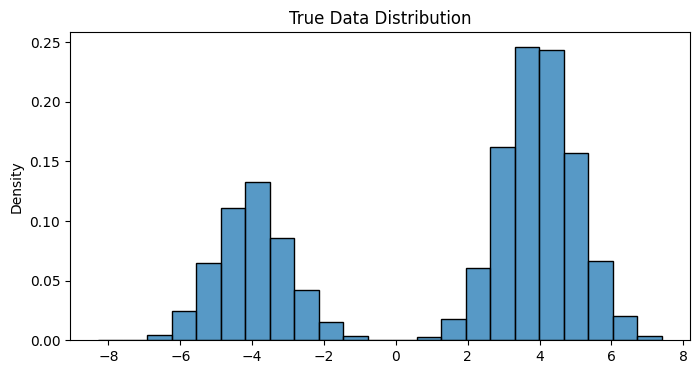

In [2]:
# Generate a dataset of 1D data from a mixture of two Gaussians
data_distribution = torch.distributions.mixture_same_family.MixtureSameFamily(
    torch.distributions.Categorical(torch.tensor([1, 2])),
    torch.distributions.Normal(torch.tensor([-4., 4.]), torch.tensor([1., 1.]))
)

dataset = data_distribution.sample(torch.Size([10000]))  # create training data set
dataset_validation = data_distribution.sample(torch.Size([1000])) # create validation data set

# Plot the dataset distribution
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
sns.histplot(dataset.numpy(), stat='density', ax=ax)
ax.set_title("True Data Distribution")
plt.show()

In [3]:
# Hyperparameters
TIME_STEPS = 250
BETA = torch.tensor(0.02)
N_EPOCHS = 1000
BATCH_SIZE = 64
LEARNING_RATE = 0.8e-4

# Precompute alphas
ALPHAS = 1.0 - BETA
ALPHAS_CUMPROD = torch.cumprod(torch.full((TIME_STEPS,), ALPHAS), dim=0)

# Define the neural network that predicts the noise
# Inputs: current data (1D) and time step (1D). Output: predicted noise (1D).
g = torch.nn.Sequential(
    torch.nn.Linear(2, 64),
    torch.nn.ReLU(),
    torch.nn.Linear(64, 64),
    torch.nn.ReLU(),
    torch.nn.Linear(64, 64),
    torch.nn.ReLU(),
    torch.nn.Linear(64, 1)
)

optimizer = torch.optim.Adam(g.parameters(), lr=LEARNING_RATE)

  0%|          | 0/1000 [00:00<?, ?it/s]

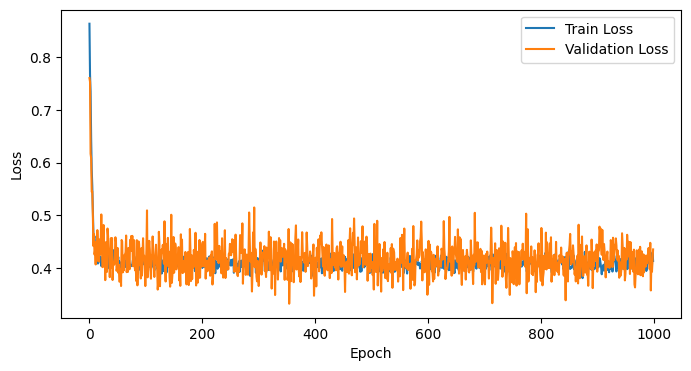

In [4]:
# Training loop
epochs = tqdm(range(N_EPOCHS))
train_losses = []
val_losses = []

for e in epochs:
    g.train()
    indices = torch.randperm(dataset.shape[0])
    shuffled_dataset = dataset[indices]

    total_loss = 0.0
    for i in range(0, shuffled_dataset.shape[0] - BATCH_SIZE, BATCH_SIZE):
        # x0 shape: [BATCH_SIZE, 1]
        x0 = shuffled_dataset[i:i + BATCH_SIZE].unsqueeze(1)

        # Sample t uniformly between 1 and TIME_STEPS
        t = torch.randint(1, TIME_STEPS + 1, (x0.shape[0], 1))

        # Sample noise
        noise = torch.randn_like(x0)

        # Get alpha_cumprod for the sampled t (t is 1-indexed)
        a_bar = ALPHAS_CUMPROD[t - 1]

        # Compute noisy sample x_t
        x_t = torch.sqrt(a_bar) * x0 + torch.sqrt(1.0 - a_bar) * noise

        # Normalize t for the network
        t_normalized = t.float() / TIME_STEPS

        # Predict noise
        net_input = torch.cat([x_t, t_normalized], dim=1)
        predicted_noise = g(net_input)

        # Compute loss
        loss = torch.nn.functional.mse_loss(predicted_noise, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x0.shape[0]

    avg_train_loss = total_loss / dataset.shape[0]
    train_losses.append(avg_train_loss)

    # Validation
    g.eval()
    with torch.no_grad():
        x0_val = dataset_validation.unsqueeze(1)
        t_val = torch.randint(1, TIME_STEPS + 1, (x0_val.shape[0], 1))
        noise_val = torch.randn_like(x0_val)
        a_bar_val = ALPHAS_CUMPROD[t_val - 1]
        x_t_val = torch.sqrt(a_bar_val) * x0_val + torch.sqrt(1.0 - a_bar_val) * noise_val
        t_normalized_val = t_val.float() / TIME_STEPS

        net_input_val = torch.cat([x_t_val, t_normalized_val], dim=1)
        predicted_noise_val = g(net_input_val)

        val_loss = torch.nn.functional.mse_loss(predicted_noise_val, noise_val)
        val_losses.append(val_loss.item())

    epochs.set_postfix(train_loss=avg_train_loss, val_loss=val_loss.item())

# Plot loss curve
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [5]:
def sample_reverse(g, count, return_history=False):
    """
    Sample from the model by applying the reverse diffusion process
    """
    g.eval()
    # Start from pure noise
    x = torch.randn((count, 1))

    history = [x.detach().numpy().copy()]

    with torch.no_grad():
        for t_step in reversed(range(1, TIME_STEPS + 1)):
            t = torch.full((count, 1), t_step)
            t_normalized = t.float() / TIME_STEPS

            net_input = torch.cat([x, t_normalized], dim=1)
            predicted_noise = g(net_input)

            alpha_t = ALPHAS
            alpha_bar_t = ALPHAS_CUMPROD[t_step - 1]

            if t_step > 1:
                z = torch.randn_like(x)
            else:
                z = torch.zeros_like(x)

            # Reverse step according to DDPM
            x = (1.0 / torch.sqrt(alpha_t)) * (x - ((1.0 - alpha_t) / torch.sqrt(1.0 - alpha_bar_t)) * predicted_noise) + torch.sqrt(BETA) * z

            # Save history at regular intervals
            if t_step % 50 == 0 or t_step == 1:
                history.append(x.detach().numpy().copy())

    if return_history:
        return x, history
    return x

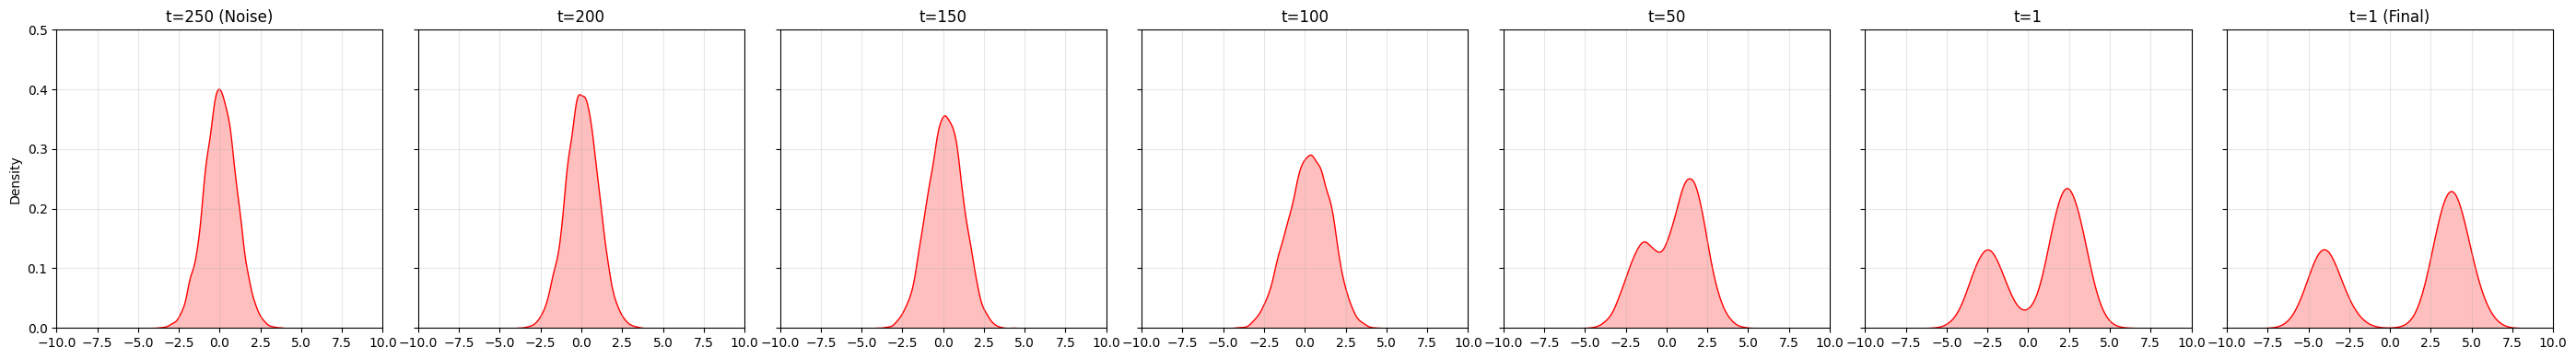

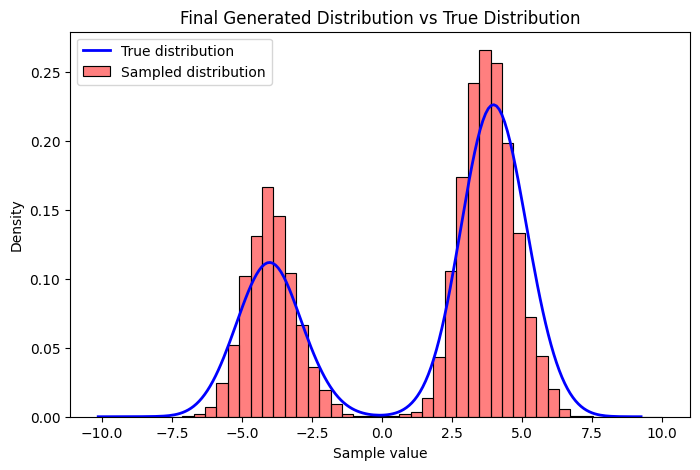

In [9]:
# Generate samples and get history for visualization
samples, history = sample_reverse(g, 10000, return_history=True)
samples = samples.detach().numpy()

# Plot the transformation of samples over time
num_plots = len(history)
fig, axes = plt.subplots(1, num_plots, figsize=(4 * num_plots, 4), sharey=True)

# Dynamic labels based on the actual history collected
# history[0] is noise (t=250), then steps 200, 150, 100, 50, 1
labels = []
for i in range(num_plots):
    if i == 0:
        labels.append(f"t={TIME_STEPS} (Noise)")
    elif i == num_plots - 1:
        labels.append("t=1 (Final)")
    else:
        # Corresponding to the % 50 logic in sample_reverse
        t_val = TIME_STEPS - (i * 50)
        labels.append(f"t={max(1, t_val)}")

for i in range(num_plots):
    sns.kdeplot(history[i].flatten(), ax=axes[i], color='red', fill=True)
    axes[i].set_title(labels[i])
    axes[i].set_xlim(-10, 10)
    axes[i].set_ylim(0, 0.5)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Final plot comparing true vs generated
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
bins = np.linspace(-10, 10, 50)
sns.kdeplot(dataset.numpy(), ax=ax, color='blue', label='True distribution', linewidth=2)
sns.histplot(samples.flatten(), ax=ax, bins=bins, color='red', label='Sampled distribution', stat='density', alpha=0.5)
ax.legend()
ax.set_xlabel('Sample value')
ax.set_ylabel('Density')
ax.set_title('Final Generated Distribution vs True Distribution')
plt.show()

### Explanation of Results
As we can see from the progressive visualizations, the reverse diffusion process begins at $t=250$ with samples that follow a standard normal distribution (pure Gaussian noise, centered around 0). As the reverse process iterates backward to $t=0$, the trained MLP iteratively predicts and removes the noise step by step.

We observe the probability mass gradually shifting and splitting from a single central peak into two distinct peaks. By the final step ($t=0$), the generated samples closely match the true bimodal data distribution, successfully capturing the mixture of two Gaussians centered at -4 and 4 with a standard deviation of 1.